In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

PROJECT_DIR = Path("/content/drive/MyDrive/DERİNMODEL")

PROCESSED_DATA_DIR = PROJECT_DIR / "01_veri_seti" / "islenmis_veri"

OUTPUT_DIR = PROJECT_DIR / "03_ciktilar"
GRAPH_DIR = OUTPUT_DIR / "grafikler" / "4_hazir_model_sonuclari"
TABLE_DIR = OUTPUT_DIR / "tablolar"
MODEL_DIR = PROJECT_DIR / "04_modeller" / "hazir_modeller"

for path in [GRAPH_DIR, TABLE_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Proje klasörü:", PROJECT_DIR)
print("İşlenmiş veri var mı?:", PROCESSED_DATA_DIR.exists())
print("İşlenmiş veri:", PROCESSED_DATA_DIR)
print("Hazır model kayıt klasörü:", MODEL_DIR)
print("Grafik kayıt klasörü:", GRAPH_DIR)
print("Tablo kayıt klasörü:", TABLE_DIR)

Proje klasörü: /content/drive/MyDrive/DERİNMODEL
İşlenmiş veri var mı?: True
İşlenmiş veri: /content/drive/MyDrive/DERİNMODEL/01_veri_seti/islenmis_veri
Hazır model kayıt klasörü: /content/drive/MyDrive/DERİNMODEL/04_modeller/hazir_modeller
Grafik kayıt klasörü: /content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/4_hazir_model_sonuclari
Tablo kayıt klasörü: /content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar


In [3]:
IMG_SIZE_TL = (224, 224)
BATCH_SIZE_TL = 16
SEED = 42

train_dir = PROCESSED_DATA_DIR / "train"
validation_dir = PROCESSED_DATA_DIR / "validation"
test_dir = PROCESSED_DATA_DIR / "test"

train_dataset_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    shuffle=True,
    seed=SEED
)

validation_dataset_tl = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    shuffle=False
)

test_dataset_tl = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    shuffle=False
)

class_names_tl = train_dataset_tl.class_names
print("Sınıf sırası:", class_names_tl)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset_tl = train_dataset_tl.prefetch(AUTOTUNE)
validation_dataset_tl = validation_dataset_tl.prefetch(AUTOTUNE)
test_dataset_tl = test_dataset_tl.prefetch(AUTOTUNE)

print("Train batch sayısı:", len(train_dataset_tl))
print("Validation batch sayısı:", len(validation_dataset_tl))
print("Test batch sayısı:", len(test_dataset_tl))

Found 2760 files belonging to 2 classes.
Found 690 files belonging to 2 classes.
Found 3450 files belonging to 2 classes.
Sınıf sırası: ['kusurlu', 'kusursuz']
Train batch sayısı: 173
Validation batch sayısı: 44
Test batch sayısı: 216


In [4]:
# TensorFlow klasör sırası: kusurlu=0, kusursuz=1
# Biz proje boyunca kusurlu=1, kusursuz=0 olarak kullanacağız.
# Bu yüzden label değerlerini ters çeviriyoruz: yeni_label = 1 - eski_label

def invert_binary_label(image, label):
    return image, 1 - label

train_dataset_tl = train_dataset_tl.map(invert_binary_label, num_parallel_calls=AUTOTUNE)
validation_dataset_tl = validation_dataset_tl.map(invert_binary_label, num_parallel_calls=AUTOTUNE)
test_dataset_tl = test_dataset_tl.map(invert_binary_label, num_parallel_calls=AUTOTUNE)

print("Etiketler ters çevrildi.")
print("Yeni anlam:")
print("0 = kusursuz")
print("1 = kusurlu")

Etiketler ters çevrildi.
Yeni anlam:
0 = kusursuz
1 = kusurlu


In [5]:
# Hazır model için class weight
# Train dağılımı:
# kusurlu: 357
# kusursuz: 2403

class_weight_tl = {
    0: 0.5742821473158551,   # kusursuz
    1: 3.865546218487395    # kusurlu
}

class_weight_tl_df = pd.DataFrame([
    {"class_index": 0, "class_name": "kusursuz", "class_weight": class_weight_tl[0]},
    {"class_index": 1, "class_name": "kusurlu", "class_weight": class_weight_tl[1]},
])

class_weight_tl_path = TABLE_DIR / "dagm_2007_transfer_learning_class_weight.csv"
class_weight_tl_df.to_csv(class_weight_tl_path, index=False)

print("Transfer learning class weight değerleri:")
print(class_weight_tl)
print("Class weight tablosu kaydedildi:")
print(class_weight_tl_path)

display(class_weight_tl_df)

Transfer learning class weight değerleri:
{0: 0.5742821473158551, 1: 3.865546218487395}
Class weight tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_transfer_learning_class_weight.csv


,class_index,class_name,class_weight
0,0,kusursuz,0.574282
1,1,kusurlu,3.865546


In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import regularizers

IMG_SHAPE_TL = IMG_SIZE_TL + (3,)

data_augmentation_tl = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.10),
], name="transfer_learning_augmentation")

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SHAPE_TL
)

# İlk aşamada hazır model gövdesini donduruyoruz
base_model.trainable = False

inputs = layers.Input(shape=IMG_SHAPE_TL)

x = data_augmentation_tl(inputs)

# EfficientNet kendi preprocessing yapısına uygun çalışır
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.40)(x)

x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.50)(x)

# Çıkış: kusurlu olma olasılığı
outputs = layers.Dense(1, activation="sigmoid")(x)

tl_model = models.Model(inputs, outputs, name="DAGM_EfficientNetB0_Transfer_Learning")

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

tl_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "DAGM_EfficientNetB0_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_learning_augmentation  │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,131,876 (15.76 MB)

 Trainable params: 82,177 (321.00 KB)

 Non-trainable params: 4,049,699 (15.45 MB)

In [7]:
# EfficientNetB0 transfer learning callback ayarları

tl_model_path = MODEL_DIR / "dagm_2007_efficientnetb0_transfer_best_model.keras"
tl_log_path = TABLE_DIR / "dagm_2007_efficientnetb0_transfer_training_log.csv"

checkpoint_tl_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(tl_model_path),
    monitor="val_pr_auc",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping_tl_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    patience=6,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

reduce_lr_tl_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

csv_logger_tl_callback = tf.keras.callbacks.CSVLogger(
    str(tl_log_path)
)

print("Transfer learning callback ayarları hazır.")
print("En iyi model kayıt yolu:", tl_model_path)
print("Eğitim log kayıt yolu:", tl_log_path)

Transfer learning callback ayarları hazır.
En iyi model kayıt yolu: /content/drive/MyDrive/DERİNMODEL/04_modeller/hazir_modeller/dagm_2007_efficientnetb0_transfer_best_model.keras
Eğitim log kayıt yolu: /content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_efficientnetb0_transfer_training_log.csv


In [8]:
EPOCHS_TL = 20

tl_history = tl_model.fit(
    train_dataset_tl,
    validation_data=validation_dataset_tl,
    epochs=EPOCHS_TL,
    class_weight=class_weight_tl,
    callbacks=[
        checkpoint_tl_callback,
        early_stopping_tl_callback,
        reduce_lr_tl_callback,
        csv_logger_tl_callback
    ],
    verbose=1
)

print("EfficientNetB0 transfer learning eğitimi tamamlandı.")
print("En iyi model kayıt yolu:")
print(tl_model_path)

Epoch 1/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.5151 - auc: 0.5354 - loss: 1.0680 - pr_auc: 0.1421 - precision: 0.1392 - recall: 0.5379
Epoch 1: val_pr_auc improved from None to 0.54561, saving model to /content/drive/MyDrive/DERİNMODEL/04_modeller/hazir_modeller/dagm_2007_efficientnetb0_transfer_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DERİNMODEL/04_modeller/hazir_modeller/dagm_2007_efficientnetb0_transfer_best_model.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 132s 676ms/step - accuracy: 0.5207 - auc: 0.5409 - loss: 1.0581 - pr_auc: 0.1469 - precision: 0.1406 - recall: 0.5294 - val_accuracy: 0.9087 - val_auc: 0.7663 - val_loss: 0.5230 - val_pr_auc: 0.5456 - val_precision: 0.8250 - val_recall: 0.3708 - learning_rate: 3.0000e-04
Epoch 2/20
171/173 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5322 - auc: 0.5409 - loss: 1.0296 - pr_auc: 0.1443 - precision: 0.1494 - recall: 0.5656
Epoch 2: val_pr_auc improved from 0.54561 to 0.58583, saving m

In [9]:
# En iyi kaydedilen EfficientNetB0 modelini yükleyelim
best_tl_model = tf.keras.models.load_model(tl_model_path)

# Test setinde değerlendirme
tl_test_results = best_tl_model.evaluate(test_dataset_tl, verbose=1)

print("EfficientNetB0 Transfer Learning test sonuçları")
print("----------------------------------------------")
print("Test Loss:", tl_test_results[0])
print("Test Accuracy:", tl_test_results[1])
print("Test Precision:", tl_test_results[2])
print("Test Recall:", tl_test_results[3])
print("Test AUC:", tl_test_results[4])
print("Test PR-AUC:", tl_test_results[5])

216/216 ━━━━━━━━━━━━━━━━━━━━ 175s 783ms/step - accuracy: 0.8403 - auc: 0.8789 - loss: 0.5961 - pr_auc: 0.6846 - precision: 0.4368 - recall: 0.7379
EfficientNetB0 Transfer Learning test sonuçları
----------------------------------------------
Test Loss: 0.596088171005249
Test Accuracy: 0.840289831161499
Test Precision: 0.4367666244506836
Test Recall: 0.7378854751586914
Test AUC: 0.8789358139038086
Test PR-AUC: 0.6846050024032593


216/216 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step
Gerçek etiket sayısı: 3450
Tahmin sayısı: 3450
Confusion Matrix:
[[2564  432]
 [ 119  335]]
Classification report kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_efficientnetb0_transfer_classification_report.csv


,precision,recall,f1-score,support
kusursuz,0.955647,0.855808,0.902976,2996.00000
kusurlu,0.436767,0.737885,0.548731,454.00000
accuracy,0.840290,0.840290,0.840290,0.84029
macro avg,0.696207,0.796847,0.725853,3450.00000
weighted avg,0.887365,0.840290,0.856359,3450.00000


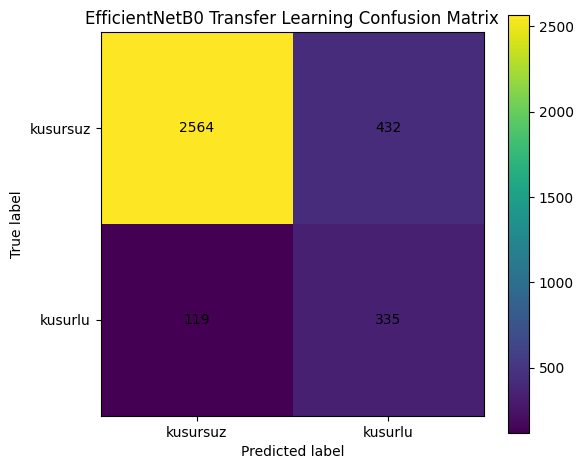

Confusion matrix grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/4_hazir_model_sonuclari/dagm_2007_efficientnetb0_transfer_confusion_matrix.png


In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gerçek etiketler: 0 = kusursuz, 1 = kusurlu
y_true_tl = []

for images, labels in test_dataset_tl:
    y_true_tl.extend(labels.numpy().ravel())

y_true_tl = np.array(y_true_tl).astype(int)

# Tahmin olasılıkları
y_prob_tl = best_tl_model.predict(test_dataset_tl).ravel()

# 0.50 threshold ile tahmin
y_pred_tl = (y_prob_tl >= 0.50).astype(int)

print("Gerçek etiket sayısı:", len(y_true_tl))
print("Tahmin sayısı:", len(y_pred_tl))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

print("Confusion Matrix:")
print(cm_tl)

report_tl = classification_report(
    y_true_tl,
    y_pred_tl,
    target_names=["kusursuz", "kusurlu"],
    output_dict=True
)

report_tl_df = pd.DataFrame(report_tl).transpose()

tl_report_path = TABLE_DIR / "dagm_2007_efficientnetb0_transfer_classification_report.csv"
report_tl_df.to_csv(tl_report_path)

print("Classification report kaydedildi:")
print(tl_report_path)

display(report_tl_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm_tl)
plt.title("EfficientNetB0 Transfer Learning Confusion Matrix")
plt.colorbar()

classes = ["kusursuz", "kusurlu"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm_tl.shape[0]):
    for j in range(cm_tl.shape[1]):
        plt.text(j, i, cm_tl[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

tl_cm_path = GRAPH_DIR / "dagm_2007_efficientnetb0_transfer_confusion_matrix.png"
plt.savefig(tl_cm_path, dpi=300)
plt.show()

print("Confusion matrix grafiği kaydedildi:")
print(tl_cm_path)

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

threshold_values = np.arange(0.05, 1.00, 0.05)

tl_threshold_records = []

for threshold in threshold_values:
    y_pred_thr = (y_prob_tl >= threshold).astype(int)

    acc = accuracy_score(y_true_tl, y_pred_thr)
    precision = precision_score(y_true_tl, y_pred_thr, zero_division=0)
    recall = recall_score(y_true_tl, y_pred_thr, zero_division=0)
    f1 = f1_score(y_true_tl, y_pred_thr, zero_division=0)

    cm = confusion_matrix(y_true_tl, y_pred_thr)
    tn, fp, fn, tp = cm.ravel()

    tl_threshold_records.append({
        "threshold": round(float(threshold), 2),
        "accuracy": acc,
        "kusurlu_precision": precision,
        "kusurlu_recall": recall,
        "kusurlu_f1": f1,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    })

tl_threshold_df = pd.DataFrame(tl_threshold_records)

tl_threshold_path = TABLE_DIR / "dagm_2007_efficientnetb0_transfer_threshold_analizi.csv"
tl_threshold_df.to_csv(tl_threshold_path, index=False)

print("EfficientNetB0 threshold analizi kaydedildi:")
print(tl_threshold_path)

display(tl_threshold_df)

EfficientNetB0 threshold analizi kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_efficientnetb0_transfer_threshold_analizi.csv


,threshold,accuracy,kusurlu_precision,kusurlu_recall,kusurlu_f1,true_negative,false_positive,false_negative,true_positive
0,0.05,0.131594,0.131594,1.000000,0.232582,0,2996,0,454
1,0.10,0.132174,0.131671,1.000000,0.232701,2,2994,0,454
2,0.15,0.150145,0.133865,0.997797,0.236060,65,2931,1,453
3,0.20,0.214203,0.142540,0.991189,0.249238,289,2707,4,450
4,0.25,0.288406,0.154404,0.984581,0.266945,548,2448,7,447
5,0.30,0.381159,0.172320,0.973568,0.292812,873,2123,12,442
6,0.35,0.515942,0.206280,0.940529,0.338352,1353,1643,27,427
7,0.40,0.665507,0.267596,0.887665,0.411224,1893,1103,51,403
8,0.45,0.780290,0.356604,0.832599,0.499339,2314,682,76,378
9,0.50,0.840290,0.436767,0.737885,0.548731,2564,432,119,335


Seçilen threshold: 0.6
Confusion Matrix:
[[2835  161]
 [ 189  265]]
0.60 threshold classification report kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_efficientnetb0_transfer_threshold_060_classification_report.csv


,precision,recall,f1-score,support
kusursuz,0.937500,0.946262,0.941860,2996.000000
kusurlu,0.622066,0.583700,0.602273,454.000000
accuracy,0.898551,0.898551,0.898551,0.898551
macro avg,0.779783,0.764981,0.772067,3450.000000
weighted avg,0.895991,0.898551,0.897173,3450.000000


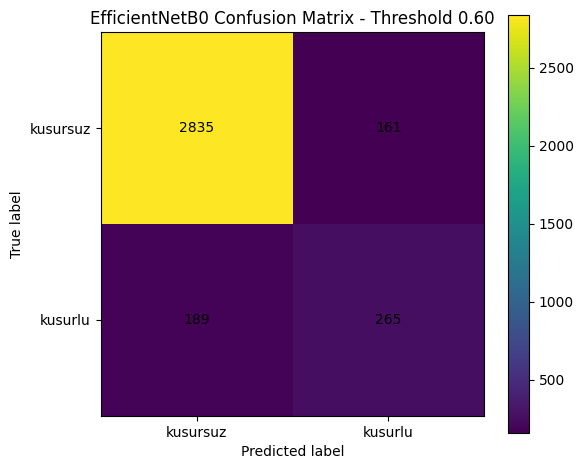

0.60 threshold confusion matrix grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/4_hazir_model_sonuclari/dagm_2007_efficientnetb0_transfer_threshold_060_confusion_matrix.png


In [12]:
SELECTED_TL_THRESHOLD = 0.60

y_pred_tl_selected = (y_prob_tl >= SELECTED_TL_THRESHOLD).astype(int)

cm_tl_selected = confusion_matrix(y_true_tl, y_pred_tl_selected)

print("Seçilen threshold:", SELECTED_TL_THRESHOLD)
print("Confusion Matrix:")
print(cm_tl_selected)

report_tl_selected = classification_report(
    y_true_tl,
    y_pred_tl_selected,
    target_names=["kusursuz", "kusurlu"],
    output_dict=True
)

report_tl_selected_df = pd.DataFrame(report_tl_selected).transpose()

selected_tl_report_path = TABLE_DIR / "dagm_2007_efficientnetb0_transfer_threshold_060_classification_report.csv"
report_tl_selected_df.to_csv(selected_tl_report_path)

print("0.60 threshold classification report kaydedildi:")
print(selected_tl_report_path)

display(report_tl_selected_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm_tl_selected)
plt.title("EfficientNetB0 Confusion Matrix - Threshold 0.60")
plt.colorbar()

classes = ["kusursuz", "kusurlu"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm_tl_selected.shape[0]):
    for j in range(cm_tl_selected.shape[1]):
        plt.text(j, i, cm_tl_selected[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

selected_tl_cm_path = GRAPH_DIR / "dagm_2007_efficientnetb0_transfer_threshold_060_confusion_matrix.png"
plt.savefig(selected_tl_cm_path, dpi=300)
plt.show()

print("0.60 threshold confusion matrix grafiği kaydedildi:")
print(selected_tl_cm_path)

In [13]:
transfer_summary_records = [
    {
        "model": "EfficientNetB0 Transfer Learning",
        "egitim_stratejisi": "ImageNet ağırlıkları, frozen base model, class_weight, data augmentation",
        "image_size": "224x224",
        "selected_threshold": 0.60,
        "test_accuracy": 0.898551,
        "kusurlu_precision": 0.622066,
        "kusurlu_recall": 0.583700,
        "kusurlu_f1": 0.602273,
        "true_negative": 2835,
        "false_positive": 161,
        "false_negative": 189,
        "true_positive": 265,
        "yorum": "Kendi CNN modellerine göre daha dengeli ve başarılı sonuç verdi."
    }
]

transfer_summary_df = pd.DataFrame(transfer_summary_records)

transfer_summary_path = TABLE_DIR / "dagm_2007_efficientnetb0_transfer_final_ozet.csv"
transfer_summary_df.to_csv(transfer_summary_path, index=False)

print("EfficientNetB0 final özet tablosu kaydedildi:")
print(transfer_summary_path)

display(transfer_summary_df)

EfficientNetB0 final özet tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_efficientnetb0_transfer_final_ozet.csv


,model,egitim_stratejisi,image_size,selected_threshold,test_accuracy,kusurlu_precision,kusurlu_recall,kusurlu_f1,true_negative,false_positive,false_negative,true_positive,yorum
0,EfficientNetB0 Transfer Learning,"ImageNet ağırlıkları, frozen base model, class...",224x224,0.6,0.898551,0.622066,0.5837,0.602273,2835,161,189,265,Kendi CNN modellerine göre daha dengeli ve baş...


In [14]:
final_comparison_records = [
    {
        "model": "Kendi CNN Model 1",
        "yontem": "Regularized CNN",
        "threshold": 0.50,
        "accuracy": 0.8661,
        "kusurlu_precision": 0.4718,
        "kusurlu_recall": 0.1476,
        "kusurlu_f1": 0.2248,
        "yorum": "Accuracy yüksek olsa da kusurlu sınıfı yakalama başarısı düşüktür."
    },
    {
        "model": "Kendi CNN Model 2",
        "yontem": "Balanced batch CNN",
        "threshold": 0.50,
        "accuracy": 0.8843,
        "kusurlu_precision": 0.8985,
        "kusurlu_recall": 0.1366,
        "kusurlu_f1": 0.2371,
        "yorum": "Precision yüksek fakat kusurlu recall çok düşük kalmıştır."
    },
    {
        "model": "Kendi CNN Model 3",
        "yontem": "256x256 + Focal Loss",
        "threshold": 0.40,
        "accuracy": 0.4939,
        "kusurlu_precision": 0.1670,
        "kusurlu_recall": 0.7137,
        "kusurlu_f1": 0.2707,
        "yorum": "Kusurlu yakalama arttı fakat yanlış pozitif sayısı çok yükseldi."
    },
    {
        "model": "EfficientNetB0",
        "yontem": "Transfer Learning",
        "threshold": 0.60,
        "accuracy": 0.8986,
        "kusurlu_precision": 0.6221,
        "kusurlu_recall": 0.5837,
        "kusurlu_f1": 0.6023,
        "yorum": "En dengeli ve en başarılı sonuç bu modelde elde edilmiştir."
    }
]

final_comparison_df = pd.DataFrame(final_comparison_records)

final_comparison_path = TABLE_DIR / "dagm_2007_final_model_karsilastirma.csv"
final_comparison_df.to_csv(final_comparison_path, index=False)

print("Final model karşılaştırma tablosu kaydedildi:")
print(final_comparison_path)

display(final_comparison_df)

Final model karşılaştırma tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_final_model_karsilastirma.csv


,model,yontem,threshold,accuracy,kusurlu_precision,kusurlu_recall,kusurlu_f1,yorum
0,Kendi CNN Model 1,Regularized CNN,0.5,0.8661,0.4718,0.1476,0.2248,Accuracy yüksek olsa da kusurlu sınıfı yakalam...
1,Kendi CNN Model 2,Balanced batch CNN,0.5,0.8843,0.8985,0.1366,0.2371,Precision yüksek fakat kusurlu recall çok düşü...
2,Kendi CNN Model 3,256x256 + Focal Loss,0.4,0.4939,0.1670,0.7137,0.2707,Kusurlu yakalama arttı fakat yanlış pozitif sa...
3,EfficientNetB0,Transfer Learning,0.6,0.8986,0.6221,0.5837,0.6023,En dengeli ve en başarılı sonuç bu modelde eld...


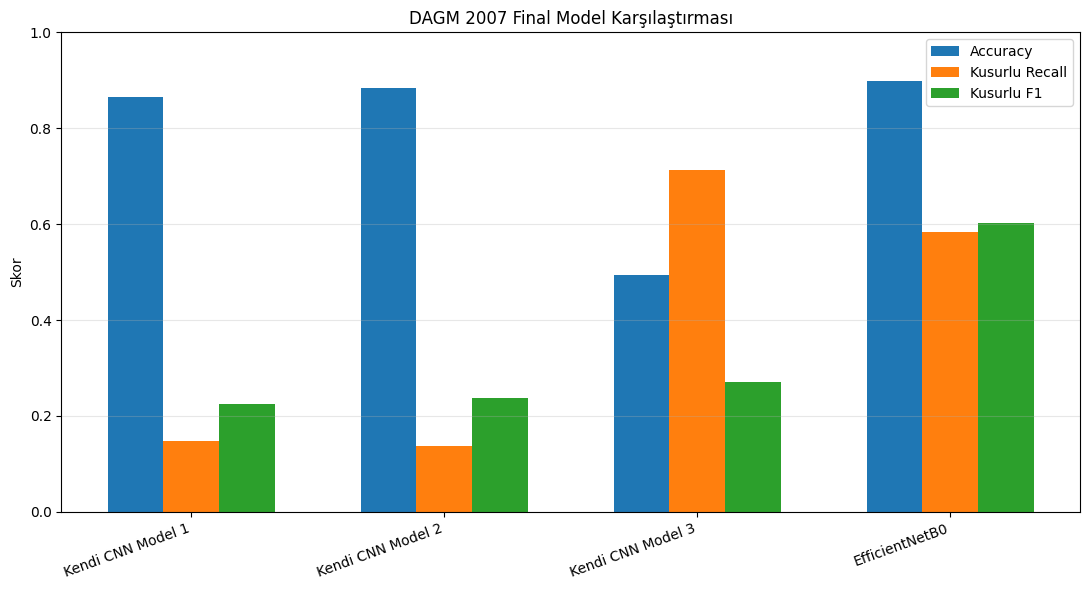

Final model karşılaştırma grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/4_hazir_model_sonuclari/dagm_2007_final_model_karsilastirma.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(11, 6))

x = np.arange(len(final_comparison_df))
width = 0.22

plt.bar(x - width, final_comparison_df["accuracy"], width, label="Accuracy")
plt.bar(x, final_comparison_df["kusurlu_recall"], width, label="Kusurlu Recall")
plt.bar(x + width, final_comparison_df["kusurlu_f1"], width, label="Kusurlu F1")

plt.xticks(x, final_comparison_df["model"], rotation=20, ha="right")
plt.ylabel("Skor")
plt.title("DAGM 2007 Final Model Karşılaştırması")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

final_comparison_graph_path = GRAPH_DIR / "dagm_2007_final_model_karsilastirma.png"
plt.savefig(final_comparison_graph_path, dpi=300)
plt.show()

print("Final model karşılaştırma grafiği kaydedildi:")
print(final_comparison_graph_path)

In [16]:
final_result_text = """
DAGM 2007 Optik Kusur Tespiti Projesi - Final Model Değerlendirmesi

Bu projede DAGM 2007 veri seti kullanılarak kusurlu / kusursuz binary classification problemi ele alınmıştır.
Veri setinde Class1-Class6 arası 6 sınıf kullanılmıştır. Label klasörlerinde maske dosyası bulunan görseller kusurlu,
label dosyası bulunmayan görseller kusursuz olarak etiketlenmiştir.

Hazır Train/Test ayrımı korunmuştur. Validation seti yalnızca Train verisi içinden ayrılmıştır.
Böylece veri sızıntısı önlenmiştir.

Deneylerde üç farklı kendi CNN modeli ve bir transfer learning modeli denenmiştir.

En başarılı model:
EfficientNetB0 Transfer Learning

Seçilen threshold:
0.60

Final test sonuçları:
Accuracy: 0.8986
Kusurlu Precision: 0.6221
Kusurlu Recall: 0.5837
Kusurlu F1-score: 0.6023

Confusion Matrix:
[[2835, 161],
 [189, 265]]

Yorum:
EfficientNetB0 modeli kendi CNN modellerine göre daha dengeli sonuç vermiştir.
Kusurlu sınıfta hem precision hem recall değerleri daha dengeli hale gelmiştir.
Threshold 0.60 seçildiğinde yanlış pozitif sayısı azalmış, F1-score yükselmiştir.
Bu nedenle final model olarak EfficientNetB0 Transfer Learning modeli seçilmiştir.
"""

final_text_path = TABLE_DIR / "dagm_2007_final_sonuc_ozeti.txt"

with open(final_text_path, "w", encoding="utf-8") as f:
    f.write(final_result_text)

print("Final sonuç özeti kaydedildi:")
print(final_text_path)

print(final_result_text)

Final sonuç özeti kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_final_sonuc_ozeti.txt

DAGM 2007 Optik Kusur Tespiti Projesi - Final Model Değerlendirmesi

Bu projede DAGM 2007 veri seti kullanılarak kusurlu / kusursuz binary classification problemi ele alınmıştır.
Veri setinde Class1-Class6 arası 6 sınıf kullanılmıştır. Label klasörlerinde maske dosyası bulunan görseller kusurlu,
label dosyası bulunmayan görseller kusursuz olarak etiketlenmiştir.

Hazır Train/Test ayrımı korunmuştur. Validation seti yalnızca Train verisi içinden ayrılmıştır.
Böylece veri sızıntısı önlenmiştir.

Deneylerde üç farklı kendi CNN modeli ve bir transfer learning modeli denenmiştir.

En başarılı model:
EfficientNetB0 Transfer Learning

Seçilen threshold:
0.60

Final test sonuçları:
Accuracy: 0.8986
Kusurlu Precision: 0.6221
Kusurlu Recall: 0.5837
Kusurlu F1-score: 0.6023

Confusion Matrix:
[[2835, 161],
 [189, 265]]

Yorum:
EfficientNetB0 modeli kendi CNN modellerine göre daha 

In [17]:
from pathlib import Path

print("PROJE ÇIKTI KONTROLÜ")
print("-------------------")

important_files = [
    TABLE_DIR / "dagm_2007_binary_manifest.csv",
    TABLE_DIR / "dagm_2007_final_model_karsilastirma.csv",
    TABLE_DIR / "dagm_2007_efficientnetb0_transfer_final_ozet.csv",
    TABLE_DIR / "dagm_2007_efficientnetb0_transfer_threshold_060_classification_report.csv",
    TABLE_DIR / "dagm_2007_final_sonuc_ozeti.txt",
    GRAPH_DIR / "dagm_2007_final_model_karsilastirma.png",
    GRAPH_DIR / "dagm_2007_efficientnetb0_transfer_threshold_060_confusion_matrix.png",
    MODEL_DIR / "dagm_2007_efficientnetb0_transfer_best_model.keras"
]

for file_path in important_files:
    print(file_path.name, "->", "VAR" if file_path.exists() else "YOK")
    print(file_path)
    print()

PROJE ÇIKTI KONTROLÜ
-------------------
dagm_2007_binary_manifest.csv -> VAR
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_binary_manifest.csv

dagm_2007_final_model_karsilastirma.csv -> VAR
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_final_model_karsilastirma.csv

dagm_2007_efficientnetb0_transfer_final_ozet.csv -> VAR
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_efficientnetb0_transfer_final_ozet.csv

dagm_2007_efficientnetb0_transfer_threshold_060_classification_report.csv -> VAR
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_efficientnetb0_transfer_threshold_060_classification_report.csv

dagm_2007_final_sonuc_ozeti.txt -> VAR
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_final_sonuc_ozeti.txt

dagm_2007_final_model_karsilastirma.png -> VAR
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/4_hazir_model_sonuclari/dagm_2007_final_model_karsilastirma.png

dagm_2007_efficientnetb0_t

# DAGM 2007 Veri Seti ile Optik Kusur Tespiti

Bu projede DAGM 2007 Competition Dataset kullanılarak endüstriyel yüzeylerde optik kusur tespiti yapılmıştır. Problem, görüntülerin kusurlu veya kusursuz olarak sınıflandırılması şeklinde ele alınmıştır.

## Kullanılan Veri Seti

Veri seti DAGM 2007 optik inspeksiyon veri setidir. Çalışmada Class1-Class6 arası toplam 6 sınıf kullanılmıştır. Her sınıf içerisinde Train ve Test klasörleri bulunmaktadır. Görsellerin kusurlu olup olmadığı Label klasörü üzerinden belirlenmiştir.

Label klasöründe ilgili görsele ait maske dosyası varsa görsel kusurlu, maske dosyası yoksa kusursuz kabul edilmiştir.

## Veri Bölme Stratejisi

Hazır veri setindeki orijinal Test bölümü korunmuştur. Test verisi eğitim veya doğrulama aşamasında kullanılmamıştır. Validation seti yalnızca Train verisi içerisinden ayrılmıştır. Bu sayede veri sızıntısı önlenmiştir.

Kullanılan veri dağılımı:

- Train: 2760 görsel
- Validation: 690 görsel
- Test: 3450 görsel

Sınıf dağılımı:

- Train kusurlu: 357
- Train kusursuz: 2403
- Validation kusurlu: 89
- Validation kusursuz: 601
- Test kusurlu: 454
- Test kusursuz: 2996

## Veri Ön İşleme

Veri ön işleme aşamasında orijinal klasör yapısı analiz edilmiştir. Label dosyalarına göre kusurlu/kusursuz etiketleri oluşturulmuştur. Ardından model eğitimine uygun olacak şekilde train, validation ve test klasörleri oluşturulmuştur.

Görüntüler model girişine uygun boyutlara getirilmiş, normalizasyon işlemi model içerisinde uygulanmıştır. Eğitim aşamasında overfitting riskini azaltmak için data augmentation, dropout, L2 regularization, early stopping ve class weight gibi yöntemler kullanılmıştır.

## Kendi CNN Modelleri

Projede üç farklı kendi CNN modeli denenmiştir:

1. Regularized CNN
2. Balanced Batch CNN
3. 256x256 görüntü boyutu ve Focal Loss kullanan CNN

Kendi CNN modellerinde sınıf dengesizliği önemli bir problem oluşturmuştur. Bazı modeller yüksek accuracy üretse de kusurlu sınıfı yakalama başarısı düşük kalmıştır. Focal Loss kullanılan üçüncü model kusurlu sınıfı yakalama oranını artırmıştır; ancak yanlış pozitif sayısı yüksek olmuştur.

## Transfer Learning Modeli

Kendi CNN modellerine ek olarak EfficientNetB0 tabanlı transfer learning modeli kullanılmıştır. EfficientNetB0 modeli ImageNet üzerinde önceden eğitilmiş ağırlıklarla yüklenmiş, ilk aşamada gövde katmanları dondurulmuş ve yalnızca sınıflandırma katmanları eğitilmiştir.

EfficientNetB0 modeli kendi CNN modellerine göre daha dengeli sonuç vermiştir.

## Final Model Sonucu

Final model olarak EfficientNetB0 Transfer Learning modeli seçilmiştir. Threshold analizi sonucunda 0.60 threshold değeri daha dengeli sonuç verdiği için seçilmiştir.

Final test sonuçları:

- Accuracy: 0.8986
- Kusurlu Precision: 0.6221
- Kusurlu Recall: 0.5837
- Kusurlu F1-score: 0.6023

Confusion Matrix:

| Gerçek / Tahmin | Kusursuz | Kusurlu |
|---|---:|---:|
| Kusursuz | 2835 | 161 |
| Kusurlu | 189 | 265 |

Bu sonuçlara göre model 454 kusurlu görüntünün 265 tanesini doğru yakalamıştır. 189 kusurlu görüntü kaçırılmıştır. Kusursuz görüntülerde ise 2996 görüntünün 2835 tanesi doğru sınıflandırılmış, 161 tanesi yanlışlıkla kusurlu olarak işaretlenmiştir.

## Sonuç

EfficientNetB0 Transfer Learning modeli, kendi CNN modellerine göre daha başarılı ve dengeli sonuç üretmiştir. Özellikle kusurlu sınıf için precision ve recall değerleri daha dengeli hale gelmiştir. Bu nedenle final model olarak EfficientNetB0 seçilmiştir.

Bununla birlikte kusurlu görüntüleri kaçırma oranı tamamen ortadan kalkmamıştır. Daha iyi sonuçlar için ileride farklı transfer learning modelleri, fine-tuning, segmentasyon tabanlı yaklaşımlar veya anomali tespiti yöntemleri denenebilir.